<a href="https://colab.research.google.com/github/Rashmi-200/SmartWaste-AI/blob/Agent-2/SmartWaste_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
path = kagglehub.dataset_download("sumn2u/garbage-classification-v2")

Using Colab cache for faster access to the 'garbage-classification-v2' dataset.


In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("sumn2u/garbage-classification-v2")

print("Path to dataset files:", path)
# List the contents to ensure we see the folders (Metal, Glass, etc.)
print("Folders found:", os.listdir(path))

Using Colab cache for faster access to the 'garbage-classification-v2' dataset.
Path to dataset files: /kaggle/input/garbage-classification-v2
Folders found: ['metal', 'glass', 'biological', 'paper', 'battery', 'trash', 'cardboard', 'shoes', 'clothes', 'plastic']


/tmp/ipython-input-3853584107.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Category', y='Count', data=df, palette=colors)


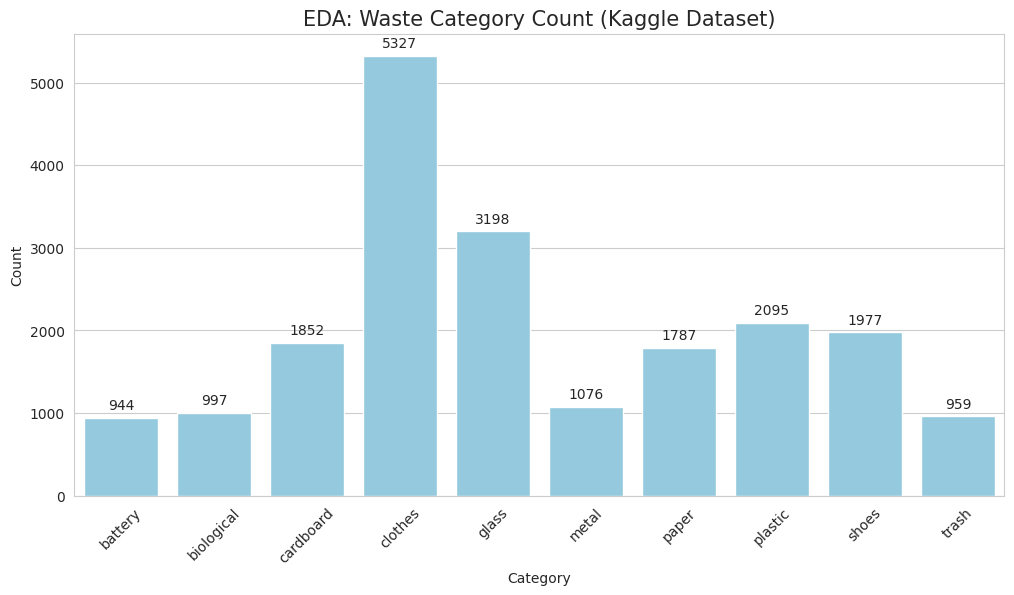


--- Visualizing Samples (Checking Image Quality) ---


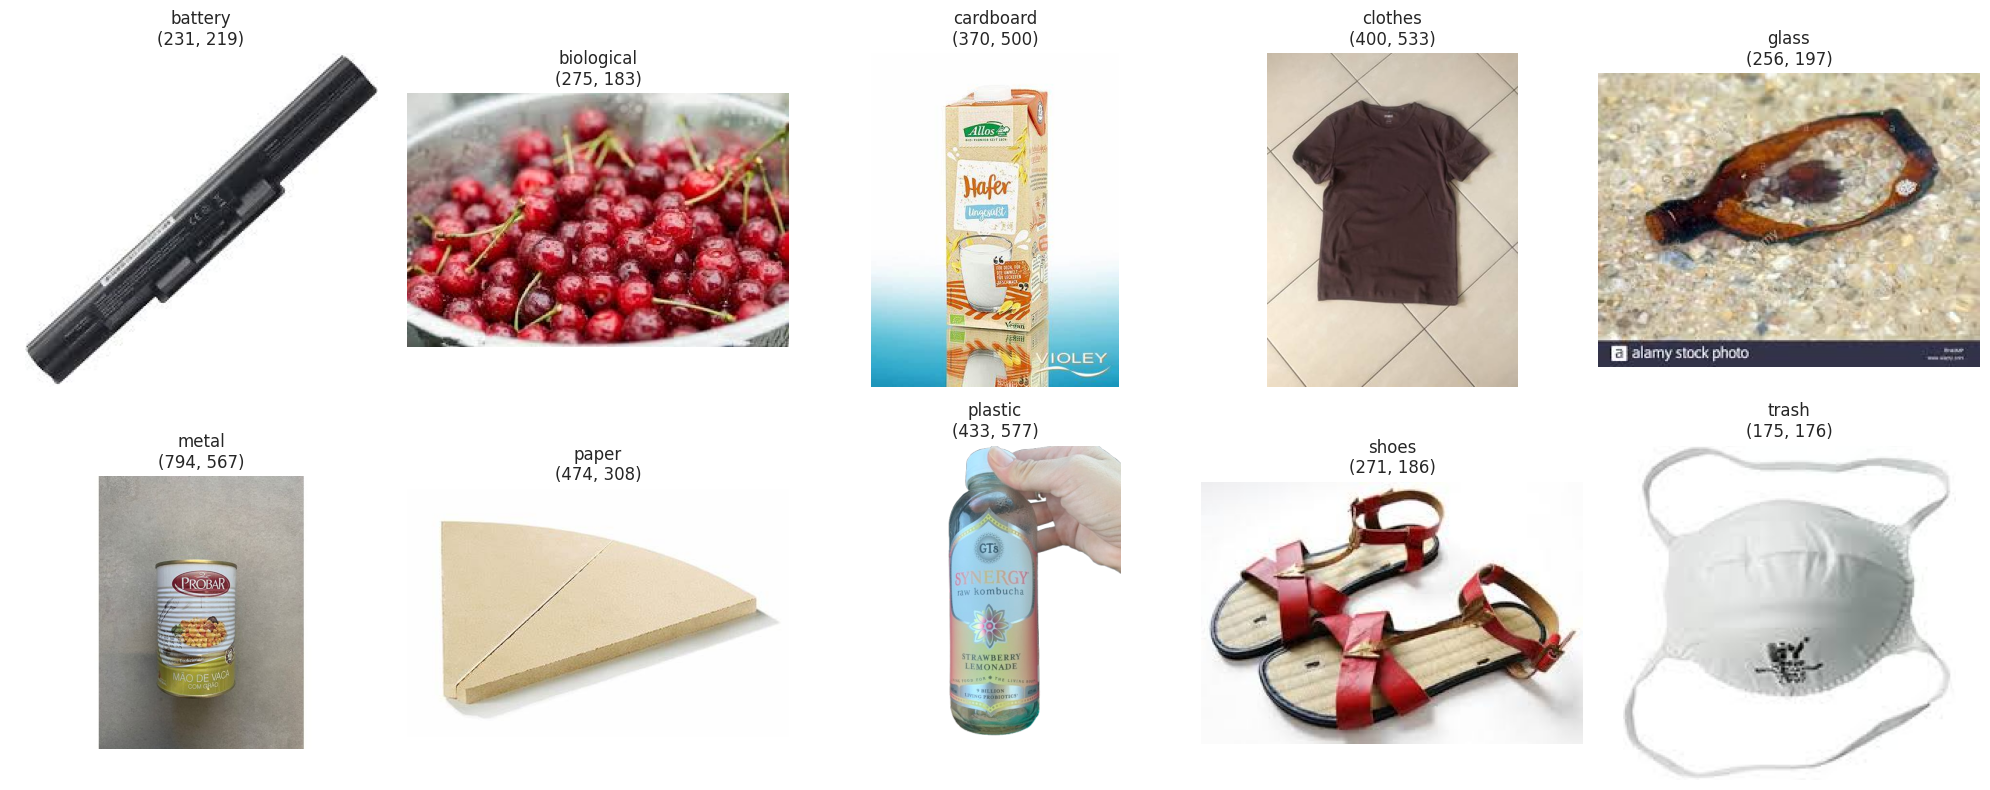

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# 1. Analyze Dataset Structure
data_info = []
categories = sorted([d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))])

for cat in categories:
    cat_path = os.path.join(path, cat)
    n_images = len(os.listdir(cat_path))
    data_info.append({'Category': cat, 'Count': n_images})

df = pd.DataFrame(data_info)

# 2. Plot Class Distribution
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
# Highlighting 'Biological' as it is your perishable target
colors = ['orange' if x == 'Biological' else 'skyblue' for x in df['Category']]
ax = sns.barplot(x='Category', y='Count', data=df, palette=colors)

plt.title('EDA: Waste Category Count (Kaggle Dataset)', fontsize=15)
plt.xticks(rotation=45)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')
plt.show()

# 3. Display Sample Images from each Category
print("\n--- Visualizing Samples (Checking Image Quality) ---")
plt.figure(figsize=(20, 8))

for i, cat in enumerate(categories):
    cat_path = os.path.join(path, cat)
    img_name = os.listdir(cat_path)[0] # Get the first image
    img_full_path = os.path.join(cat_path, img_name)

    img = Image.open(img_full_path)

    plt.subplot(2, 5, i+1)
    plt.imshow(img)
    plt.title(f"{cat}\n{img.size}") # Shows resolution
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Configuration for Preprocessing & Augmentation
# We use horizontal_flip and rotation because waste can be in any orientation
datagen = ImageDataGenerator(
    rescale=1./255,            # Normalization: converts 0-255 to 0.0-1.0
    rotation_range=20,         # Randomly rotate images
    zoom_range=0.15,           # Randomly zoom in
    width_shift_range=0.2,     # Randomly shift horizontally
    height_shift_range=0.2,    # Randomly shift vertically
    horizontal_flip=True,      # Flip images
    validation_split=0.2       # RESERVE 20% of data for testing (Validation)
)

# 2. Training Data Loader
train_generator = datagen.flow_from_directory(
    path,                      # The path from kagglehub
    target_size=(224, 224),    # Standard size for MobileNetV2/ResNet50
    batch_size=32,
    class_mode='categorical',
    subset='training',         # 80% for training
    shuffle=True
)

# 3. Validation Data Loader
validation_generator = datagen.flow_from_directory(
    path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',       # 20% for testing
    shuffle=False
)

Found 16174 images belonging to 10 classes.
Found 4038 images belonging to 10 classes.


In [ ]:
# Print the class indices to ensure the agent knows which number is which class
print("Class Indices Mapping:")
print(train_generator.class_indices)

# Check the shape of one batch
sample_images, sample_labels = next(train_generator)
print(f"\nBatch Image Shape: {sample_images.shape}") # Should be (32, 224, 224, 3)

Class Indices Mapping:
{'battery': 0, 'biological': 1, 'cardboard': 2, 'clothes': 3, 'glass': 4, 'metal': 5, 'paper': 6, 'plastic': 7, 'shoes': 8, 'trash': 9}

Batch Image Shape: (32, 224, 224, 3)


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

# 1. Load the pre-trained MobileNetV2 (without the top classification layer)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# 2. Freeze the base model (don't retrain the early layers yet)
base_model.trainable = False

# 3. Add custom layers for your 10 waste classes
x = base_model.output
x = GlobalAveragePooling2D()(x) # Flattens the features
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x) # Prevents overfitting
predictions = Dense(10, activation='softmax')(x) # 10 classes output

# 4. Final Agent Model
model = Model(inputs=base_model.input, outputs=predictions)

# 5. Compile
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# Train the model
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    steps_per_epoch=len(train_generator),
    validation_steps=len(validation_generator)
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
506/506 ━━━━━━━━━━━━━━━━━━━━ 1177s 2s/step - accuracy: 0.7543 - loss: 0.7616 - val_accuracy: 0.8413 - val_loss: 0.5214
Epoch 2/10
506/506 ━━━━━━━━━━━━━━━━━━━━ 1212s 2s/step - accuracy: 0.8865 - loss: 0.3414 - val_accuracy: 0.8564 - val_loss: 0.4781
Epoch 3/10
506/506 ━━━━━━━━━━━━━━━━━━━━ 1389s 3s/step - accuracy: 0.9028 - loss: 0.2880 - val_accuracy: 0.8650 - val_loss: 0.4520
Epoch 4/10
506/506 ━━━━━━━━━━━━━━━━━━━━ 1456s 3s/step - accuracy: 0.9091 - loss: 0.2637 - val_accuracy: 0.8645 - val_loss: 0.4502
Epoch 5/10
506/506 ━━━━━━━━━━━━━━━━━━━━ 1384s 3s/step - accuracy: 0.9197 - loss: 0.2290 - val_accuracy: 0.8623 - val_loss: 0.4557
Epoch 6/10
506/506 ━━━━━━━━━━━━━━━━━━━━ 1432s 3s/step - accuracy: 0.9265 - loss: 0.2082 - val_accuracy: 0.8730 - val_loss: 0.4131
Epoch 7/10
506/506 ━━━━━━━━━━━━━━━━━━━━ 1359s 3s/step - accuracy: 0.9267 - loss: 0.2142 - val_accuracy: 0.8697 - val_loss: 0.4582
Epoch 8/10
506/506 ━━━━━━━━━━━━━━━━━━━━ 1407s 3s/step - accuracy: 0.9292 - loss: 0.2053 - 

In [ ]:
def get_waste_report(prediction_index):
    # Map from your Class Indices result
    class_map = {v: k for k, v in train_generator.class_indices.items()}
    detected_item = class_map[prediction_index]

    # Logic for Perishable
    if detected_item == 'biological':
        status = "PERISHABLE (Organic Waste)"
    else:
        status = "NON-PERISHABLE (Inorganic/Recyclable)"

    return detected_item, status

# Example of how it will look:
# item, status = get_waste_report(1)
# print(f"Agent Prediction: {item} -> {status}")

Saving images.jfif to images.jfif
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


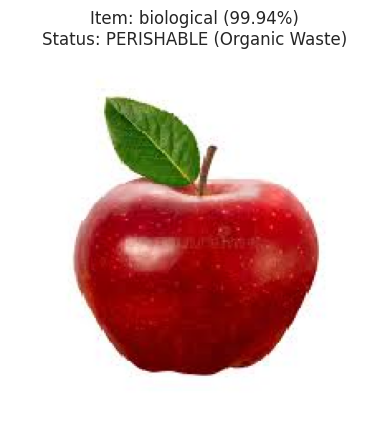

--- Agent Report ---
Detected: BIOLOGICAL
Category: PERISHABLE (Organic Waste)
Confidence: 99.94%


In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# 1. Upload the image
uploaded = files.upload()

for fn in uploaded.keys():
    # 2. Preprocess the image to match training (224x224)
    img_path = fn
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) # Create a batch of 1
    img_array /= 255.0 # Normalize just like training

    # 3. Model Prediction
    predictions = model.predict(img_array)
    score = tf.nn.softmax(predictions[0]) # Get probabilities
    class_idx = np.argmax(predictions[0])
    confidence = 100 * np.max(predictions[0])

    # 4. Use your Logic Function
    detected_item, status = get_waste_report(class_idx)

    # 5. Show Results
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Item: {detected_item} ({confidence:.2f}%)\nStatus: {status}")
    plt.show()

    print(f"--- Agent Report ---")
    print(f"Detected: {detected_item.upper()}")
    print(f"Category: {status}")
    print(f"Confidence: {confidence:.2f}%")

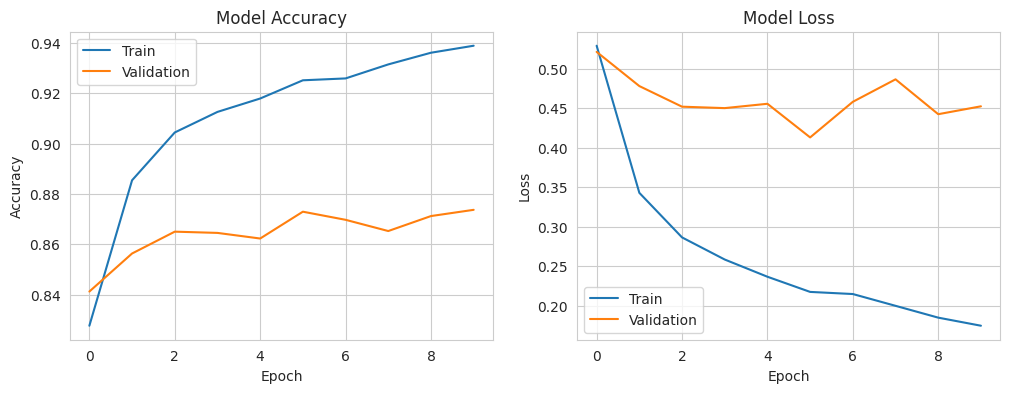

In [ ]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.show()

In [ ]:
# Save the model to your Google Colab files
model.save('waste_classifier_agent.h5')
print("Model Saved Successfully!")

# To download it to your computer:
from google.colab import files
files.download('waste_classifier_agent.h5')

Model Saved Successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

127/127 ━━━━━━━━━━━━━━━━━━━━ 237s 2s/step


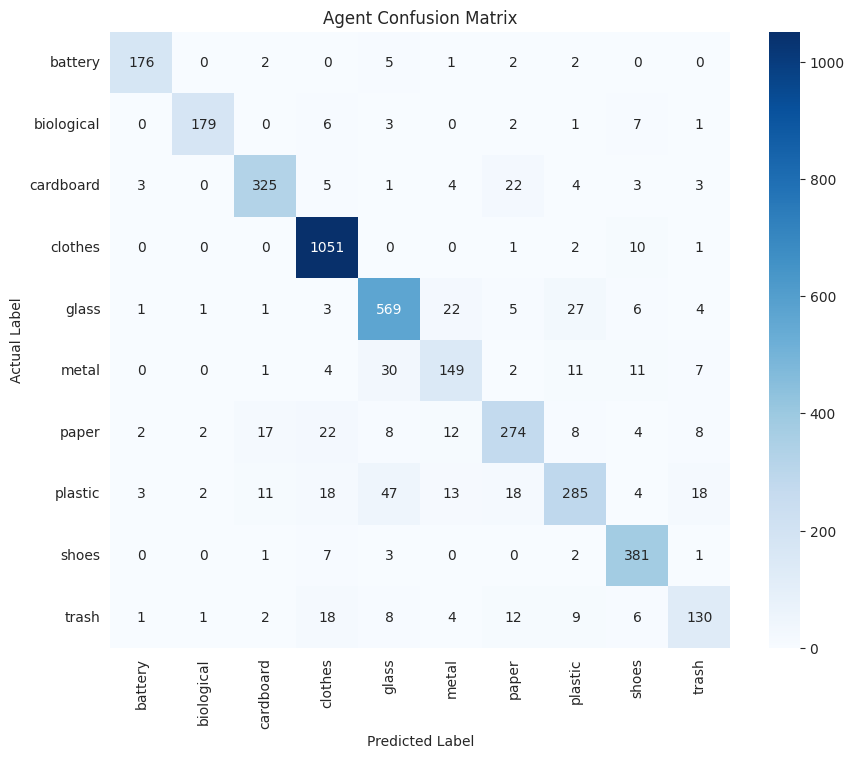

In [ ]:
# 1. Get the class names from the generator
class_names = list(train_generator.class_indices.keys())

# 2. Run the Confusion Matrix code again
from sklearn.metrics import confusion_matrix
import seaborn as sns

validation_generator.reset()
Y_pred = model.predict(validation_generator)
y_pred = np.argmax(Y_pred, axis=1)

cm = confusion_matrix(validation_generator.classes, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Agent Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
# Unique Metadata for each waste type
waste_metadata = {
    'battery': {
        'hazard': '🔴 HIGH',
        'impact': 'Toxic chemicals can leak into soil.',
        'decomposition': '100+ years',
        'instruction': 'Take to a designated e-waste collection point.'
    },
    'biological': {
        'hazard': '🟢 LOW',
        'impact': 'Produces methane if buried; great for compost.',
        'decomposition': '2-6 weeks',
        'instruction': 'Place in green bin for composting.'
    },
    'cardboard': {
        'hazard': '🟢 LOW',
        'impact': 'Highly recyclable if kept dry.',
        'decomposition': '2 months',
        'instruction': 'Flatten and place in paper recycling.'
    },
    'clothes': {
        'hazard': '🟡 LOW',
        'impact': 'Synthetic fibers take centuries to break down.',
        'decomposition': '20-200 years',
        'instruction': 'Donate if usable; otherwise, textile recycling.'
    },
    'glass': {
        'hazard': '🟡 MEDIUM (Sharp)',
        'impact': 'Indefinite lifespan; 100% recyclable.',
        'decomposition': '1 million years',
        'instruction': 'Rinse and place in glass-only bin.'
    },
    'metal': {
        'hazard': '🟡 MEDIUM',
        'impact': 'Mining new metal is energy-intensive.',
        'decomposition': '50-500 years',
        'instruction': 'Infinite recycling potential. Place in blue bin.'
    },
    'paper': {
        'hazard': '🟢 LOW',
        'impact': 'Can be recycled 5-7 times.',
        'decomposition': '2-6 weeks',
        'instruction': 'Ensure it is not soiled with food.'
    },
    'plastic': {
        'hazard': '🟠 MEDIUM',
        'impact': 'Breaks down into microplastics.',
        'decomposition': '450 years',
        'instruction': 'Check the resin code on the bottom.'
    },
    'shoes': {
        'hazard': '🟡 LOW',
        'impact': 'Complex materials make recycling difficult.',
        'decomposition': '30-40 years',
        'instruction': 'Look for specialized shoe recycling programs.'
    },
    'trash': {
        'hazard': '🟡 MEDIUM',
        'impact': 'Destination: Landfill.',
        'decomposition': 'Varies',
        'instruction': 'Last resort. Try to segregate more carefully.'
    }
}

In [ ]:
def final_agent_report(img_path, model, confidence_threshold=70.0):
    # 1. Preprocess and Predict
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_array)
    class_idx = np.argmax(preds[0])
    confidence = np.max(preds[0]) * 100

    # 2. Get Class Name
    class_names = list(train_generator.class_indices.keys())
    detected_item = class_names[class_idx]

    # 3. Apply Safety Gate
    if confidence < confidence_threshold:
        return f"⚠️ UNCERTAIN ({confidence:.1f}%): Object is unclear. Please re-scan."

    # 4. Fetch Perishable Logic & Metadata
    is_perishable = "PERISHABLE" if detected_item == 'biological' else "NON-PERISHABLE"
    info = waste_metadata.get(detected_item)

    # 5. Build the Beautiful Report
    print(f"--- 🛡️ WASTE INTELLIGENCE REPORT ---")
    print(f"IDENTIFIED : {detected_item.upper()}")
    print(f"CATEGORY   : {is_perishable}")
    print(f"CONFIDENCE : {confidence:.2f}%")
    print(f"HAZARD     : {info['hazard']}")
    print(f"ECO-IMPACT : {info['impact']}")
    print(f"DECOMP TIME: {info['decomposition']}")
    print(f"NEXT STEP  : {info['instruction']}")
    print(f"------------------------------------")

    plt.imshow(img)
    plt.axis('off')
    plt.show()

# Test it!
final_agent_report("C:\Users\USER\Desktop\Golden+Retrievers+dans+pet+care.webp", model)

FileNotFoundError: [Errno 2] No such file or directory: 'your_test_image.jpg'

Upload an image to test the agent:


Saving download (1).jfif to download (1) (1).jfif

--- 🛡️ WASTE INTELLIGENCE REPORT ---
IDENTIFIED : PLASTIC
CATEGORY   : NON-PERISHABLE (Inorganic)
CONFIDENCE : 100.00%
HAZARD     : 🟠 MEDIUM
ECO-IMPACT : Microplastic risk.
DECOMP TIME: 450 years
NEXT STEP  : Check the resin code.
------------------------------------


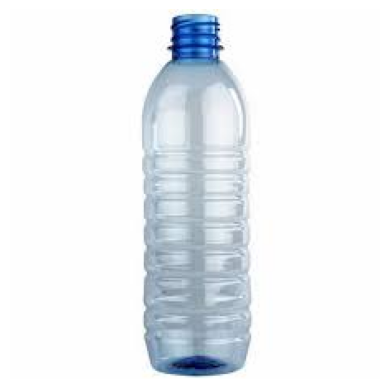

In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# 1. Knowledge Base
waste_metadata = {
    'battery': {'hazard': '🔴 HIGH', 'impact': 'Toxic chemicals can leak.', 'decomposition': '100+ years', 'instruction': 'Take to e-waste collection.'},
    'biological': {'hazard': '🟢 LOW', 'impact': 'Great for compost.', 'decomposition': '2-6 weeks', 'instruction': 'Place in green bin.'},
    'cardboard': {'hazard': '🟢 LOW', 'impact': 'Recyclable if dry.', 'decomposition': '2 months', 'instruction': 'Flatten for paper recycling.'},
    'clothes': {'hazard': '🟡 LOW', 'impact': 'Takes centuries to break down.', 'decomposition': '20-200 years', 'instruction': 'Donate or textile recycle.'},
    'glass': {'hazard': '🟡 MEDIUM (Sharp)', 'impact': '100% recyclable.', 'decomposition': '1 million years', 'instruction': 'Rinse and place in glass bin.'},
    'metal': {'hazard': '🟡 MEDIUM', 'impact': 'Infinite recycling potential.', 'decomposition': '50-500 years', 'instruction': 'Place in blue bin.'},
    'paper': {'hazard': '🟢 LOW', 'impact': 'Recyclable 5-7 times.', 'decomposition': '2-6 weeks', 'instruction': 'Keep it clean and dry.'},
    'plastic': {'hazard': '🟠 MEDIUM', 'impact': 'Microplastic risk.', 'decomposition': '450 years', 'instruction': 'Check the resin code.'},
    'shoes': {'hazard': '🟡 LOW', 'impact': 'Complex to recycle.', 'decomposition': '30-40 years', 'instruction': 'Look for shoe-specific programs.'},
    'trash': {'hazard': '🟡 MEDIUM', 'impact': 'Destination: Landfill.', 'decomposition': 'Varies', 'instruction': 'Last resort; try to segregate more.'}
}

# 2. The Smart Agent Function
def final_agent_report(img_path, model, confidence_threshold=70.0):
    # Image Preprocessing
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Prediction
    preds = model.predict(img_array, verbose=0)
    class_idx = np.argmax(preds[0])
    confidence = np.max(preds[0]) * 100
    class_names = list(train_generator.class_indices.keys())

    # --- SAFETY GATE & GUESS LOGIC ---
    if confidence < confidence_threshold:
        # Get the top 2 indices
        top_2_indices = np.argsort(preds[0])[-2:]
        guess_1 = class_names[top_2_indices[1]]
        guess_2 = class_names[top_2_indices[0]]

        print(f"\n⚠️ UNCERTAIN ({confidence:.1f}%): I'm not sure what this is.")
        print(f"🔎 ANALYSIS: It looks a bit like '{guess_1}' or '{guess_2}', but I need a clearer photo.")

        plt.imshow(img)
        plt.axis('off')
        plt.show()
        return

    # --- SUCCESSFUL CLASSIFICATION ---
    detected_item = class_names[class_idx].lower()
    is_perishable = "PERISHABLE (Organic)" if detected_item == 'biological' else "NON-PERISHABLE (Inorganic)"
    info = waste_metadata.get(detected_item, {"hazard": "N/A", "impact": "N/A", "decomposition": "N/A", "instruction": "Check guidelines."})

    print(f"\n--- 🛡️ WASTE INTELLIGENCE REPORT ---")
    print(f"IDENTIFIED : {detected_item.upper()}")
    print(f"CATEGORY   : {is_perishable}")
    print(f"CONFIDENCE : {confidence:.2f}%")
    print(f"HAZARD     : {info['hazard']}")
    print(f"ECO-IMPACT : {info['impact']}")
    print(f"DECOMP TIME: {info['decomposition']}")
    print(f"NEXT STEP  : {info['instruction']}")
    print(f"------------------------------------")

    plt.imshow(img)
    plt.axis('off')
    plt.show()

# 3. Execution
print("Upload an image to test the agent:")
uploaded = files.upload()

for filename in uploaded.keys():
    final_agent_report(filename, model)

In [ ]:
!pip install fastapi nest-asyncio pyngrok uvicorn python-multipart

In [ ]:
!pip install fastapi nest-asyncio pyngrok uvicorn python-multipart

from fastapi import FastAPI, UploadFile, File
from fastapi.middleware.cors import CORSMiddleware
import uvicorn
import nest_asyncio
from pyngrok import ngrok
import io

app = FastAPI()

# Allow React to talk to this API
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_methods=["*"],
    allow_headers=["*"],
)

@app.post("/predict")
async def predict_waste(file: UploadFile = File(...)):
    # 1. Read uploaded image
    contents = await file.read()
    img = image.load_img(io.BytesIO(contents), target_size=(224, 224))

    # 2. Preprocess
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # 3. Model Logic
    preds = model.predict(img_array, verbose=0)
    class_idx = np.argmax(preds[0])
    confidence = float(np.max(preds[0]) * 100)
    class_names = list(train_generator.class_indices.keys())
    detected_item = class_names[class_idx].lower()

    # 4. Apply your Metadata Logic
    is_perishable = "PERISHABLE" if detected_item == 'biological' else "NON-PERISHABLE"
    info = waste_metadata.get(detected_item, {})

    return {
        "item": detected_item.upper(),
        "category": is_perishable,
        "confidence": round(confidence, 2),
        "hazard": info.get('hazard'),
        "impact": info.get('impact'),
        "decomp": info.get('decomposition'),
        "instruction": info.get('instruction')
    }

# Start the Tunnel (You need a free ngrok authtoken)
auth_token = "37LGv5JCzWGUIiU9MoXdVgs4IZW_48MeKMaCVZMyvd6tz5kqi"
ngrok.set_auth_token(auth_token)
public_url = ngrok.connect(8000).public_url
print(f"React should connect to: {public_url}/predict")

nest_asyncio.apply()
import uvicorn
import nest_asyncio

# 1. Allow nested event loops (required for Colab/Jupyter)
nest_asyncio.apply()

# 2. Run the server using the configuration object
# This avoids the "asyncio.run()" conflict
if __name__ == "__main__":
    config = uvicorn.Config(app=app, host="0.0.0.0", port=8000, log_level="info")
    server = uvicorn.Server(config)
    await server.serve() # Notice the 'await' here

React should connect to: https://leptosomatic-unpresciently-marisa.ngrok-free.dev/predict


INFO:     Started server process [398]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


INFO:     2402:4000:b241:63c3:a891:4ec1:6e5c:e570:0 - "POST /predict/predict HTTP/1.1" 404 Not Found
INFO:     2402:4000:b241:63c3:a891:4ec1:6e5c:e570:0 - "POST /predict/predict HTTP/1.1" 404 Not Found
INFO:     2402:4000:b241:63c3:a891:4ec1:6e5c:e570:0 - "POST /predict HTTP/1.1" 200 OK
INFO:     2402:4000:b241:63c3:a891:4ec1:6e5c:e570:0 - "POST /predict HTTP/1.1" 200 OK


INFO:     Shutting down
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
INFO:     Finished server process [398]


In [ ]:
from pyngrok import ngrok
ngrok.kill()